# LangGraph 챗봇 구축

먼저 `LangGraph`를 사용하여 간단한 챗봇을 만들어 보겠습니다. 이 챗봇은 사용자 메시지에 직접 응답하며, 비록 간단한 구조이지만 `LangGraph`로 구축하는 핵심 개념을 모두 담고 있습니다.

`StateGraph`를 생성하는 것부터 시작합니다. `StateGraph` 객체는 챗봇의 구조를 "상태 기계(State Machine)"로 정의합니다.

`nodes`를 추가하여 챗봇이 호출할 수 있는 `llm`과 함수들을 나타내고, `edges`를 추가하여 봇이 이러한 함수들 간에 어떻게 전환하는지를 지정합니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
# !pip install -qU langchain-teddynote
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-V1-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-V1-Tutorial


## Step-by-Step 으로 배우는 LangGraph 챗봇 구축

아래에서는 LangGraph 챗봇을 구축하는 과정을 7단계로 나누어 살펴봅니다. 각 단계는 LangGraph의 핵심 개념인 State, Node, Edge, Graph와 직접 연결되어 있으므로, 순서대로 따라가며 이해하는 것을 권장합니다.

### STEP 1. 상태(State) 정의

LangGraph에서 **State(상태)**는 그래프의 모든 노드가 공유하는 데이터 구조입니다. `TypedDict`를 사용하여 정의하며, 각 노드는 이 상태를 읽고 업데이트합니다.

`messages` 필드는 `Annotated` 타입과 `add_messages` 리듀서를 사용하여 정의합니다. 이렇게 하면 새로운 메시지가 기존 메시지 목록에 자동으로 추가됩니다.

> 📖 **참고 문서**: [LangGraph Graph API](https://langchain-ai.github.io/langgraph/reference/graphs/)

아래 코드에서는 챗봇의 상태를 정의합니다.

In [3]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph import add_messages


class State(TypedDict):
    # 메시지 정의(list type 이며 add_messages 함수를 사용하여 메시지를 추가)
    messages: Annotated[list, add_messages]

### STEP 2. 노드(Node) 정의

노드(Node)는 그래프에서 실제 작업을 수행하는 단위입니다. 일반적으로 Python 함수로 정의되며, 현재 상태(State)를 입력으로 받아 처리한 후 업데이트된 상태를 반환합니다.

챗봇 노드 함수는 상태에서 메시지를 읽어 LLM에 전달하고, LLM의 응답을 새 메시지로 반환합니다. 반환된 메시지는 `add_messages` 리듀서에 의해 기존 메시지 목록에 자동으로 추가됩니다.

아래 코드에서는 LLM을 정의하고 챗봇 노드 함수를 구현합니다.

In [4]:
from langchain.chat_models import init_chat_model

# OpenAI 키를 사용할 경우 gpt-5.2, gpt-4.1-mini 등의 모델로 변경하세요.
llm = init_chat_model("claude-sonnet-4-5")


# 챗봇 함수 정의
def chatbot(state: State):
    """챗봇 노드 함수

    현재 상태의 메시지를 LLM에 전달하고,
    LLM의 응답을 새 메시지로 추가하여 반환합니다.
    """
    # 메시지 호출 및 반환
    return {"messages": [llm.invoke(state["messages"])]}

### STEP 3. 그래프(Graph) 정의, 노드 추가

`StateGraph`는 LangGraph의 핵심 클래스로, 상태 기반 워크플로우를 정의합니다. 정의한 `State` 타입을 인자로 전달하여 그래프 빌더를 생성합니다.

`add_node()` 메서드를 사용하여 그래프에 노드를 추가합니다. 첫 번째 인자는 노드의 이름(문자열)이고, 두 번째 인자는 해당 노드에서 실행될 함수입니다.

아래 코드에서는 StateGraph를 생성하고 "chatbot" 노드를 추가합니다.

In [5]:
# 그래프 생성
graph_builder = StateGraph(State)

# 노드 이름, 함수 혹은 callable 객체를 인자로 받아 노드를 추가
graph_builder.add_node("chatbot", chatbot)

**참고**

- `chatbot` 노드 함수는 현재 `State`를 입력으로 받아 "messages"라는 키 아래에 업데이트된 `messages` 목록을 포함하는 사전(TypedDict) 을 반환합니다. 

- `State`의 `add_messages` 함수는 이미 상태에 있는 메시지에 llm의 응답 메시지를 추가합니다. 

### STEP 4. 그래프 엣지(Edge) 추가

엣지(Edge)는 노드와 노드를 연결하여 그래프의 실행 흐름을 정의합니다. LangGraph에서는 `START`와 `END` 두 가지 특수 노드를 제공하여 그래프의 시작과 끝 지점을 명시적으로 지정합니다.

`START`는 그래프가 실행될 때마다 작업을 시작할 위치를 나타내며, `add_edge(START, "chatbot")`을 통해 처음으로 실행될 노드를 지정합니다.

아래 코드에서는 START 노드에서 챗봇 노드로 이어지는 엣지를 추가합니다.

In [6]:
# 시작 노드에서 챗봇 노드로의 엣지 추가
graph_builder.add_edge(START, "chatbot")

`END`는 그래프 흐름의 종료 지점을 나타냅니다. `add_edge("chatbot", END)`를 추가하면 챗봇 노드의 실행이 완료된 후 그래프가 종료됩니다.

아래 코드에서는 챗봇 노드에서 END 노드로 이어지는 엣지를 추가합니다.

In [7]:
# 그래프에 엣지 추가
graph_builder.add_edge("chatbot", END)

### STEP 5. 그래프 컴파일(compile)

`StateGraph`를 정의한 후에는 반드시 `compile()` 메서드를 호출하여 실행 가능한 형태로 변환해야 합니다. 컴파일 과정에서 노드 간 연결이 검증되고, 실행 순서가 결정됩니다.

컴파일된 그래프는 `invoke()` 또는 `stream()` 메서드를 통해 실행할 수 있습니다.

아래 코드는 정의한 그래프를 컴파일하고, 실행 가능한 `CompiledGraph` 객체를 반환합니다.

In [8]:
# 그래프 컴파일
graph = graph_builder.compile()

### STEP 6. 그래프 시각화

`langchain_teddynote.graphs` 모듈의 `visualize_graph()` 함수를 사용하면 컴파일된 그래프의 구조를 시각적으로 확인할 수 있습니다. 

시각화를 통해 노드 간의 연결 관계와 실행 흐름을 직관적으로 파악할 수 있습니다. 복잡한 그래프를 디버깅하거나 구조를 검토할 때 유용합니다.

아래 코드에서는 컴파일된 그래프를 시각화합니다.

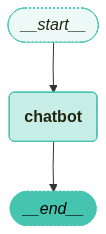

In [9]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(graph)

### STEP 7. 그래프 실행

컴파일된 그래프는 `stream_graph()` 함수를 사용하여 간편하게 실행할 수 있습니다. `langchain_teddynote` 패키지에서 제공하는 `stream_graph()`는 내부적으로 그래프 스트리밍을 처리하고 결과를 출력합니다.

입력은 딕셔너리 형태로 전달하며, `messages` 키에 사용자 메시지 튜플 `("user", 질문내용)`을 리스트로 감싸서 전달합니다.

아래 코드에서는 챗봇 그래프를 실행하고 응답을 출력합니다.

In [10]:
from langchain_teddynote.messages import stream_graph

question = "서울의 유명한 맛집 TOP 10 추천해줘"

# 그래프 실행 및 응답 출력
stream_graph(graph, {"messages": [("user", question)]})


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
# 서울 유명 맛집 TOP 10 🍽️

## 1. **광장시장** (종로구)
- 빈대떡, 마약김밥, 육회 등 전통 길거리 음식의 성지
- 저렴하고 푸짐한 한국 전통 음식

## 2. **진미평양냉면** (을지로)
- 서울 3대 평양냉면 맛집
- 고소하고 깔끔한 육수가 일품

## 3. **땀땀** (이태원/한남동)
- 미슐랭 빕구르망 선정
- 독특한 퓨전 한식 요리

## 4. **우래옥** (을지로)
- 70년 전통의 평양냉면 맛집
- 설렁탕과 불고기도 유명

## 5. **명동교자** (명동)
- 칼국수와 만두가 대표 메뉴
- 합리적인 가격에 푸짐한 양

## 6. **이문설농탕** (회기동)
- 진한 사골 국물의 설렁탕 전문점
- 24시간 영업으로 언제든 방문 가능

## 7. **박가네 양평해장국** (연남동)
- 진한 국물의 해장국 맛집
- 새벽까지 영업하는 해장 명소

## 8. **미진** (종로)
- 참숯불고기 전문점
- 60년 전통의 노포

## 9. **통인시장 도시락카페** (통인동)
- 엽전으로 먹는 재미있는 시장 도시락
- 다양한 반찬을 소량씩 맛볼 수 있음

## 10. **줄서는집** (종로/여러 지점)
- 갈비탕과 갈비찜 전문점
- 푸짐한 양과 깊은 맛

---

💡 **TIP**: 점심시간(12-1시)과 저녁시간(6-7시)에는 대기가 길 수 있으니 시간을 피해 방문하는 것을 추천합니다!

지금까지 7단계에 걸쳐 LangGraph를 사용한 기본 챗봇 구축 과정을 살펴보았습니다. State 정의부터 Node 구현, Edge 연결, 그래프 컴파일, 시각화, 실행까지의 전체 흐름을 이해하셨다면 LangGraph의 핵심 개념을 갖추신 것입니다.

아래는 지금까지의 과정을 하나의 셀로 통합한 전체 코드입니다.

## 전체 코드

앞서 7단계로 나누어 살펴본 코드를 하나의 셀로 정리하였습니다. `init_chat_model()`로 LLM을 초기화하고, `StateGraph`로 챗봇 그래프를 구성한 뒤, `stream_graph()`로 실행하는 전체 흐름을 한눈에 확인할 수 있습니다.

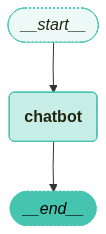


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
# 서울 유명 맛집 TOP 10 🍴

## 1. **광장시장**
- **메뉴**: 빈대떡, 마약김밥, 육회
- **위치**: 종로5가
- **특징**: 전통시장 분위기에서 즐기는 서울 대표 길거리 음식

## 2. **을지로 노가리골목**
- **메뉴**: 노가리, 각종 안주
- **위치**: 을지로3가
- **특징**: 직장인들의 성지, 저렴한 가격의 술안주

## 3. **강남 봉피양**
- **메뉴**: 양곱창, 대창
- **위치**: 강남역 인근
- **특징**: 신선한 곱창으로 유명한 맛집

## 4. **명동교자**
- **메뉴**: 칼국수, 만두
- **위치**: 명동
- **특징**: 50년 전통의 노포, 시원한 국물이 일품

## 5. **이태원 앤틱**
- **메뉴**: 다양한 세계 요리
- **위치**: 이태원
- **특징**: 이국적인 분위기의 레스토랑 밀집 지역

## 6. **진주집**
- **메뉴**: 콩나물해장국
- **위치**: 종로
- **특징**: 60년 전통의 해장국 전문점

## 7. **이촌동 돼지집**
- **메뉴**: 제육볶음, 고기
- **위치**: 이촌동
- **특징**: SNS에서 핫한 제육볶음 맛집

## 8. **북촌 손만두**
- **메뉴**: 수제 만두
- **위치**: 북촌 한옥마을
- **특징**: 한옥마을 구경과 함께 즐기는 손만두

## 9. **마포 염통골목**
- **메뉴**: 염통구이, 곱창
- **위치**: 마포구 염리동
- **특징**: 저렴하고 푸짐한 염통구이

## 10. **낙원동 떡볶이골목**
- **메뉴**: 즉석떡볶이
- **위치**: 종로 낙원동
- **특징**: 옛날식 즉석떡볶이의 진수

---
**💡 TIP**: 인기 맛집은 대기시간이 길 수 있으니 오픈시간에 맞춰 방문하거나 예약을 권장합니다!

In [11]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph import add_messages
from langchain.chat_models import init_chat_model
from langchain_teddynote.graphs import visualize_graph
from langchain_teddynote.messages import stream_graph


###### STEP 1. 상태(State) 정의 ######
class State(TypedDict):
    # 메시지 정의(list type 이며 add_messages 함수를 사용하여 메시지를 추가)
    messages: Annotated[list, add_messages]


###### STEP 2. 노드(Node) 정의 ######
# OpenAI 키를 사용할 경우 gpt-5.2, gpt-4.1-mini 등의 모델로 변경하세요.
llm = init_chat_model("claude-sonnet-4-5")


# 챗봇 함수 정의
def chatbot(state: State):
    """챗봇 노드 함수

    현재 상태의 메시지를 LLM에 전달하고,
    LLM의 응답을 새 메시지로 추가하여 반환합니다.
    """
    # 메시지 호출 및 반환
    return {"messages": [llm.invoke(state["messages"])]}


###### STEP 3. 그래프(Graph) 정의, 노드 추가 ######
# 그래프 생성
graph_builder = StateGraph(State)

# 노드 이름, 함수 혹은 callable 객체를 인자로 받아 노드를 추가
graph_builder.add_node("chatbot", chatbot)

###### STEP 4. 그래프 엣지(Edge) 추가 ######
# 시작 노드에서 챗봇 노드로의 엣지 추가
graph_builder.add_edge(START, "chatbot")

# 챗봇 노드에서 종료 노드로의 엣지 추가
graph_builder.add_edge("chatbot", END)

###### STEP 5. 그래프 컴파일(compile) ######
# 그래프 컴파일
graph = graph_builder.compile()

###### STEP 6. 그래프 시각화 ######
# 그래프 시각화
visualize_graph(graph)

###### STEP 7. 그래프 실행 ######
question = "서울의 유명한 맛집 TOP 10 추천해줘"

# 그래프 실행 및 응답 출력
stream_graph(graph, {"messages": [("user", question)]})

## 정리

이번 튜토리얼에서는 LangGraph를 활용하여 기본 챗봇을 구축하는 방법을 7단계로 학습했습니다. 주요 내용을 정리하면 다음과 같습니다.

- **State(상태)**: `TypedDict`와 `Annotated`를 사용하여 그래프의 공유 상태를 정의하고, `add_messages` 리듀서로 메시지를 자동 누적합니다.
- **Node(노드)**: Python 함수로 정의하며, 현재 상태를 입력으로 받아 LLM을 호출하고 업데이트된 상태를 반환합니다.
- **Edge(엣지)**: `START`와 `END` 특수 노드를 활용하여 그래프의 실행 흐름을 `START → chatbot → END` 순서로 연결합니다.
- **StateGraph**: `add_node()`와 `add_edge()`로 노드와 엣지를 구성하고, `compile()`로 실행 가능한 그래프를 생성합니다.
- **stream_graph**: `langchain_teddynote`의 `stream_graph()` 함수를 사용하여 그래프를 실행하고 결과를 스트리밍으로 출력합니다.

### 추가 학습 자료

더 깊이 있는 학습을 원한다면 아래 공식 문서를 살펴볼 수 있습니다.

- [LangGraph Graph API](https://langchain-ai.github.io/langgraph/reference/graphs/)
- [LangGraph 공식 문서](https://langchain-ai.github.io/langgraph/)